In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from collections import Counter, defaultdict
import json

# load project modules
from song_recommender.paths import *
from song_recommender.utils import load_config
from song_recommender.models.loader import (
    load_tag_cluster_map,
    load_tag_keys,
    load_tag_vectors,
    load_valid_tags,
    load_word2vec_tag_model,
    load_cluster_tags
)
from song_recommender.features.tag_features import add_tag_cluster_features

In [43]:
config = load_config(CONFIGS_DIR / 'embeddings.yaml')

In [44]:
train_df = pd.read_parquet(DATA_DIR / 'processed/train.parquet')
train_df = train_df[['name','artist','spotify_id','year','tag_list']]
train_df.sample(5)

,name,artist,spotify_id,year,tag_list
2766,Contagious Chemistry,You Me at Six,6nTC9DQjFfp2rNBLXzQ6QK,2010,[punk]
2672,The Truth,Good Charlotte,0eUjF7FA1vQQUtxDJmxX4p,2004,"[rock, punk, punk_rock, emo, love, pop_rock]"
7113,Can't Stand You,Slayer,0OfuVruszTjanunMnVMcv9,2003,"[metal, heavy_metal, thrash_metal, cover]"
7558,The Urban Theme,Maxwell,21xVx0n3qonzK2PXah9M1S,1996,"[instrumental, soul, funk, lounge]"
7596,Unique Is My Dove,Matisyahu,3KQFzvq19Lr4lNv4O9KZNH,2006,[reggae]


We create tag embeddings and clusters using the tag counts in our training set.

In [45]:
# define tag distribution function
def tag_distribution(df):
    tag_counts = Counter()

    for tags in df['tag_list']:
        tag_counts.update(tags)
    
    return tag_counts

In [46]:
tag_counts = tag_distribution(train_df)

tag_counts.most_common()

[('rock', 1647),
 ('indie', 917),
 ('classic_rock', 846),
 ('folk', 797),
 ('punk', 770),
 ('instrumental', 764),
 ('death_metal', 762),
 ('electronic', 740),
 ('80s', 739),
 ('ambient', 725),
 ('singer_songwriter', 699),
 ('hip_hop', 686),
 ('alternative', 682),
 ('experimental', 651),
 ('black_metal', 615),
 ('hard_rock', 591),
 ('punk_rock', 554),
 ('70s', 542),
 ('rap', 530),
 ('progressive_rock', 519),
 ('acoustic', 512),
 ('chillout', 492),
 ('indie_rock', 462),
 ('pop', 461),
 ('heavy_metal', 456),
 ('mellow', 455),
 ('metal', 422),
 ('dance', 421),
 ('chill', 407),
 ('melodic_death_metal', 407),
 ('female_vocalists', 406),
 ('alternative_rock', 405),
 ('90s', 399),
 ('00s', 399),
 ('beautiful', 376),
 ('psychedelic', 362),
 ('hardcore', 361),
 ('progressive_metal', 351),
 ('american', 348),
 ('metalcore', 326),
 ('love', 314),
 ('british', 307),
 ('60s', 300),
 ('new_wave', 298),
 ('indie_pop', 296),
 ('piano', 281),
 ('downtempo', 273),
 ('emo', 272),
 ('post_punk', 267),
 ('t

## 1. Build tag co-occurence matrix (as a dictionary)

We determine what tags appear together.

In [47]:
# create nested dictionary
co_counts = defaultdict(lambda: defaultdict(int))

for tags in train_df["tag_list"]:

    unique_tags = set(tags)

    # count tag pairs
    for t1 in unique_tags:
        for t2 in unique_tags:
            
            if t1 != t2:
                co_counts[t1][t2] += 1

In [48]:
co_counts['hard_rock']['progressive_rock']

69

## 2. View tag entropy

We identify tags that appear with many unrelated tags.

In [49]:
def tag_entropy(counts):
    total = sum(counts.values())
    probs = [c/total for c in counts.values()]

    return -sum(p * np.log(p) for p in probs)

In [50]:
tag_entropy_scores = {}

for tag, counts in co_counts.items():
    tag_entropy_scores[tag] = tag_entropy(counts)

In [51]:
entropy_df = pd.DataFrame({
    "tag": list(tag_entropy_scores.keys()),
    "entropy": list(tag_entropy_scores.values())
})

display(entropy_df.sort_values("entropy", ascending=False).head(20))
display(entropy_df.sort_values("entropy", ascending=False).tail(20))

,tag,entropy
11,cover,4.040931
23,experimental,3.922296
14,soundtrack,3.913265
52,female_vocalists,3.875596
27,instrumental,3.845009
4,rock,3.839158
61,industrial,3.821933
40,alternative,3.793640
63,german,3.792567
34,00s,3.777584


,tag,entropy
87,gothic_metal,2.869678
73,trance,2.779491
62,drum_and_bass,2.768955
94,symphonic_metal,2.739294
68,idm,2.739052
100,j_pop,2.689178
89,metalcore,2.688582
96,russian,2.672912
86,death_metal,2.667865
66,classical,2.664814


## 3. Noise removal: Positive Pointwise Mutual Information (PPMI)

PMI measures how often two tags appear together relative to chance. High PMI means two tags strongly belong together as PMI will be zero if the events of the tags occuring are independent, i.e., co-occurence is random.

$$PMI(\text{tag}_A, \text{tag}_B) = \log\left(\frac{P(A,B)}{P(A)P(B)}\right)$$

**WARNING:** PMI overestimates the association of rare words, as a single random co-occurence of two rare words can lead to a high PMI.

We create a weighted graph.

In [52]:
N = len(train_df)

pmi_edges = []

for t1 in co_counts:
    for t2, count in co_counts[t1].items():

        # individual tag probability
        p_t1 = tag_counts[t1] / N
        p_t2 = tag_counts[t2] / N

        # joint probability
        p_t1_t2 = count / N

        pmi = np.log(p_t1_t2 / (p_t1 * p_t2))

        pmi_edges.append((t1, t2, pmi, count))

In [53]:
pmi_edges

[('classic_rock', '80s', np.float64(1.0059070766842773), 211),
 ('classic_rock', 'hard_rock', np.float64(1.3285693003160148), 233),
 ('classic_rock', 'progressive_rock', np.float64(1.0180782750867796), 150),
 ('classic_rock', 'rock', np.float64(1.2070061747761227), 575),
 ('classic_rock', 'blues_rock', np.float64(1.8578579044278876), 168),
 ('classic_rock', 'british', np.float64(1.0968473080370515), 96),
 ('classic_rock', 'psychedelic', np.float64(1.179887007703059), 123),
 ('classic_rock', '60s', np.float64(2.0403613229908664), 241),
 ('classic_rock', 'blues', np.float64(1.5426691861862731), 126),
 ('classic_rock', 'psychedelic_rock', np.float64(1.5446934783755037), 115),
 ('classic_rock', 'cover', np.float64(0.7880592902031294), 31),
 ('classic_rock', 'oldies', np.float64(1.9305375002807688), 131),
 ('classic_rock', '70s', np.float64(1.861234730353507), 364),
 ('classic_rock', 'soundtrack', np.float64(0.21569443032816188), 32),
 ('classic_rock', 'mellow', np.float64(-0.05428806502421

We only want to keep meaningful co-occurences. We determine a PMI threshold.

In [54]:
# keep only positive PMI
positive_pmi = [pmi for t1, t2, pmi, count in pmi_edges if pmi > 0]

pmi_threshold = np.percentile(positive_pmi, 25)

print(pmi_threshold)

0.3817109396035422


In [55]:
filtered_pmi = [
    (t1, t2, pmi, count)
    for t1, t2, pmi, count in pmi_edges
    if pmi > config['tag_embedding']['pmi_threshold'] and count >= config['tag_embedding']['min_co_occurence']
]

### Visualize the graph

In [56]:
import networkx as nx

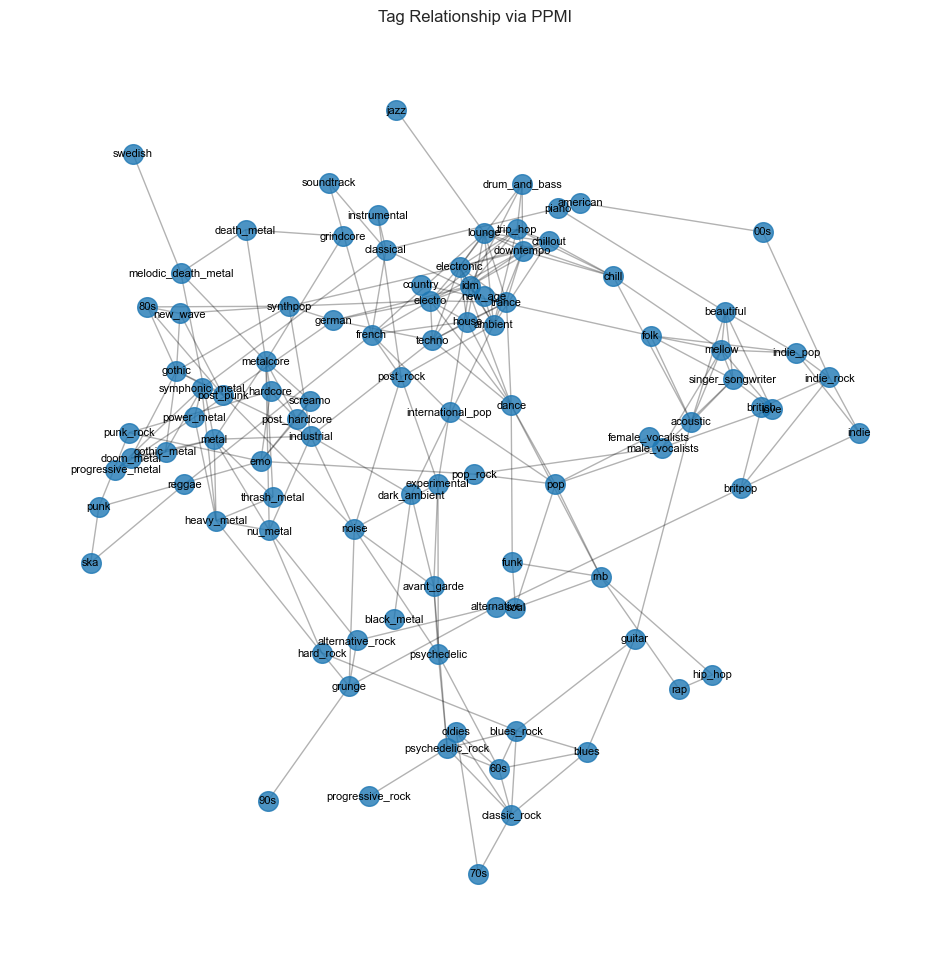

In [57]:
G = nx.Graph()

for t1, t2, pmi, count in filtered_pmi:
    G.add_edge(t1, t2, weight=pmi)

plt.figure(figsize=(12,12))

pos = nx.spring_layout(
    G,
    k=0.4,
    seed=123
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=200,
    alpha=0.8
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.3
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title("Tag Relationship via PPMI")
plt.axis("off")

plt.show()

### Use graph to extract valid tags and clean tag lists in dataframe

In [58]:
valid_tags = load_valid_tags()

In [59]:
train_df['clean_tags'] = train_df['tag_list'].apply(
    lambda tags: [t for t in tags if t in valid_tags]
    )

In [60]:
train_df['clean_tags']

0        [classic_rock, hard_rock, 80s, progressive_rock]
1       [classic_rock, hard_rock, british, blues, psyc...
2                 [classic_rock, 70s, oldies, blues_rock]
3                         [classic_rock, 70s, blues_rock]
4       [classic_rock, hard_rock, 80s, british, soundt...
                              ...                        
8097    [metal, metalcore, hardcore, melodic_death_metal]
8098                       [metalcore, progressive_metal]
8099                                          [metalcore]
8100                                          [metalcore]
8101                             [death_metal, grindcore]
Name: clean_tags, Length: 8102, dtype: object

Identify tracks with empty `clean_tags` after filtering

In [61]:
clean_tag_counts = train_df['clean_tags'].apply(lambda x: len(x))

In [62]:
keys = clean_tag_counts[clean_tag_counts == 0].keys()

In [63]:
train_df.loc[keys]

,name,artist,spotify_id,year,tag_list,clean_tags
7528,Dune,L'Arc~en~Ciel,1FW89w3bO1BslS0nRlckSK,2007,"[japanese, rock]",[]
7761,Vedy Proshlogo,Arkona,40EVn3o2OkmyAhXoPNbtDa,2008,[russian],[]
7840,Noche De Rumberos,Los Titanes,0SGxR89fYhzlNQ1Kd63tM3,2012,[latin],[]
7864,Gekkou,ASIAN KUNG-FU GENERATION,3PUUczZyDhU5hJdeCFw1tr,2018,"[japanese, j_pop]",[]
8002,Gone Too Soon,Simple Plan,14eOUtC3i0oZXS08I8WRU3,2011,[rock],[]
8015,Pida Me La,Gipsy Kings,13X7nrhPbX4aLppxjgJW9a,1994,[latin],[]
8016,Loucura,Mariza,190iXp2Kdem8WpjfWAE5Bl,2014,[world],[]
8018,Mano Dayak,Tinariwen,1KTi7LPCdfZNxG6lTWkyRx,2007,[world],[]
8019,Bruca Manigua,Ibrahim Ferrer,1iOhDhysr3BjmICFIJRpup,1999,[latin],[]
8021,Ghir Enta,Souad Massi,1azvVxRoN70dmJVqMFEZ9O,2007,[world],[]


In [64]:
print(f'Fraction of songs with no clean tags: {len(train_df.loc[keys])/len(train_df)}')

Fraction of songs with no clean tags: 0.005924463095531967


## 4. Create embeddings: Word2Vec Training

In [65]:
from gensim.models import Word2Vec

Save the model.

In [66]:
w2v = load_word2vec_tag_model()

In [67]:
w2v.wv.most_similar('black_metal')

[('progressive_metal', 0.8800703883171082),
 ('symphonic_metal', 0.8586888313293457),
 ('death_metal', 0.8515631556510925),
 ('doom_metal', 0.8403352499008179),
 ('melodic_death_metal', 0.8340424299240112),
 ('gothic_metal', 0.8205967545509338),
 ('power_metal', 0.8159421682357788),
 ('grindcore', 0.8126230835914612),
 ('dark_ambient', 0.8026027083396912),
 ('thrash_metal', 0.7878774404525757)]

In [68]:
w2v.wv.most_similar('country')

[('oldies', 0.8436354994773865),
 ('singer_songwriter', 0.8146663308143616),
 ('acoustic', 0.804357647895813),
 ('male_vocalists', 0.788073718547821),
 ('blues', 0.7507475018501282),
 ('beautiful', 0.7351102232933044),
 ('love', 0.7346153259277344),
 ('guitar', 0.7340626120567322),
 ('mellow', 0.7185574173927307),
 ('folk', 0.7157293558120728)]

We extract the tag vectors.

Save the vectors and the tag names.

In [69]:
tag_keys = load_tag_keys()
tag_vectors = load_tag_vectors()

View hierarchical ward structure from `tag_vectors`.

In [70]:
from scipy.cluster.hierarchy import linkage

ward_hierarchy = linkage(tag_vectors, method='ward')

In [71]:
import plotly.figure_factory as ff

fig = ff.create_dendrogram(tag_vectors, orientation='left',labels=tag_keys, linkagefun=lambda x: linkage(x, 'ward'))
fig.update_layout(width=800, height=1400)
fig.show()

### Hyperparameter tuning for cluster selection

In [72]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

scores = {}

for k in range(5,40):

    clusters = fcluster(
        ward_hierarchy,
        k,
        criterion="maxclust"
    )

    score = silhouette_score(tag_vectors, clusters)

    scores[k] = score

best_k = max(scores, key=scores.get)

print("Best number of clusters:", best_k)

Best number of clusters: 10


`k = 10` doesn't seem like enough clusters. Will do `k = 20`.

In [73]:
clusters = fcluster(
    ward_hierarchy,
    20,
    criterion="maxclust"
)

In [74]:
tag_cluster_map = load_tag_cluster_map()

In [75]:
cluster_tags = load_cluster_tags()

In [76]:
for c, tags in cluster_tags.items():
    print(f"\nCluster {c}")
    print(tags)


Cluster 18
['indie', 'indie_rock', 'beautiful', 'indie_pop', 'britpop']

Cluster 16
['classic_rock', '70s', '60s', 'blues', 'blues_rock', 'psychedelic_rock', 'guitar']

Cluster 17
['folk', 'singer_songwriter', 'acoustic', 'mellow', 'love', 'male_vocalists', 'oldies', 'country', 'pop_rock']

Cluster 15
['punk', 'punk_rock', 'reggae', 'ska']

Cluster 7
['instrumental', 'ambient', 'jazz']

Cluster 3
['death_metal', 'melodic_death_metal', 'metalcore', 'grindcore']

Cluster 11
['electronic', 'electro', 'techno', 'house', 'trance']

Cluster 20
['80s', 'british']

Cluster 10
['hip_hop', 'rap', 'pop', 'dance', 'soul', 'rnb', 'funk']

Cluster 19
['alternative', '00s', '90s', 'american']

Cluster 5
['experimental', 'progressive_rock', 'psychedelic', 'post_rock', 'avant_garde', 'noise', 'dark_ambient']

Cluster 1
['black_metal', 'progressive_metal', 'doom_metal', 'gothic_metal', 'symphonic_metal', 'power_metal']

Cluster 14
['hard_rock', 'alternative_rock', 'grunge']

Cluster 12
['chillout', 'ch

## 5. Add tag clustering features to dataframe

In [77]:
train_df.head()

,name,artist,spotify_id,year,tag_list,clean_tags
0,Limelight,Rush,0dnz7bSs3txd9nGY9e3Mlf,2006,"[classic_rock, hard_rock, 80s, progressive_rock]","[classic_rock, hard_rock, 80s, progressive_rock]"
1,Tales of Brave Ulysses,Cream,0a5wz1j3rnDa6IawNoZp5C,2005,"[rock, classic_rock, hard_rock, british, blues...","[classic_rock, hard_rock, british, blues, psyc..."
2,I Heard It Through the Grapevine,Creedence Clearwater Revival,0zWtqc7q1JrB1gKyI501ph,2008,"[classic_rock, 70s, oldies, cover, blues_rock]","[classic_rock, 70s, oldies, blues_rock]"
3,Gimme Three Steps,Lynyrd Skynyrd,05JDbUa3kKV7sOwok4Xq4Z,2008,"[rock, classic_rock, 70s, blues_rock]","[classic_rock, 70s, blues_rock]"
4,Flash,Queen,3kdoYsCha9XrEvwXoGoQaZ,2004,"[rock, classic_rock, hard_rock, 80s, british, ...","[classic_rock, hard_rock, 80s, british, soundt..."


In [78]:
train_df = add_tag_cluster_features(train_df, valid_tags, tag_cluster_map)
train_df.head()

,name,artist,spotify_id,year,tag_list,clean_tags,tag_set,tag_clusters,cluster_set,dominant_cluster
0,Limelight,Rush,0dnz7bSs3txd9nGY9e3Mlf,2006,"[classic_rock, hard_rock, 80s, progressive_rock]","[classic_rock, hard_rock, 80s, progressive_rock]","{classic_rock, 80s, hard_rock, progressive_rock}","[16, 14, 20, 5]","{16, 20, 5, 14}",16.0
1,Tales of Brave Ulysses,Cream,0a5wz1j3rnDa6IawNoZp5C,2005,"[rock, classic_rock, hard_rock, british, blues...","[classic_rock, hard_rock, british, blues, psyc...","{classic_rock, blues_rock, british, hard_rock,...","[16, 14, 20, 16, 5, 16, 16, 16]","{16, 20, 5, 14}",16.0
2,I Heard It Through the Grapevine,Creedence Clearwater Revival,0zWtqc7q1JrB1gKyI501ph,2008,"[classic_rock, 70s, oldies, cover, blues_rock]","[classic_rock, 70s, oldies, blues_rock]","{classic_rock, blues_rock, 70s, oldies}","[16, 16, 17, 16]","{16, 17}",16.0
3,Gimme Three Steps,Lynyrd Skynyrd,05JDbUa3kKV7sOwok4Xq4Z,2008,"[rock, classic_rock, 70s, blues_rock]","[classic_rock, 70s, blues_rock]","{classic_rock, blues_rock, 70s}","[16, 16, 16]",{16},16.0
4,Flash,Queen,3kdoYsCha9XrEvwXoGoQaZ,2004,"[rock, classic_rock, hard_rock, 80s, british, ...","[classic_rock, hard_rock, 80s, british, soundt...","{80s, classic_rock, british, soundtrack, hard_...","[16, 14, 20, 20, 6]","{16, 20, 14, 6}",20.0


In [79]:
train_df['dominant_cluster'].value_counts()

dominant_cluster
10.0    968
16.0    782
1.0     738
17.0    694
3.0     665
15.0    594
18.0    539
7.0     468
2.0     424
5.0     372
11.0    366
14.0    305
19.0    293
12.0    268
13.0    157
4.0     148
6.0     107
20.0     82
9.0      66
8.0      18
Name: count, dtype: int64

In [80]:
train_df.loc[train_df['dominant_cluster'] == 20]

,name,artist,spotify_id,year,tag_list,clean_tags,tag_set,tag_clusters,cluster_set,dominant_cluster
4,Flash,Queen,3kdoYsCha9XrEvwXoGoQaZ,2004,"[rock, classic_rock, hard_rock, 80s, british, ...","[classic_rock, hard_rock, 80s, british, soundt...","{80s, classic_rock, british, soundtrack, hard_...","[16, 14, 20, 20, 6]","{16, 20, 14, 6}",20.0
125,Blue Jean,David Bowie,2Q0bbtlsHknlGyRvbHp9wE,1993,"[rock, pop, classic_rock, 80s, british, new_wave]","[pop, classic_rock, 80s, british, new_wave]","{80s, classic_rock, new_wave, british, pop}","[10, 16, 20, 20, 4]","{16, 10, 20, 4}",20.0
137,Invisible Sun,The Police,0dOK1b1RzpIg0MWrkIiG6u,1995,"[rock, classic_rock, 80s, british, new_wave]","[classic_rock, 80s, british, new_wave]","{british, classic_rock, 80s, new_wave}","[16, 20, 20, 4]","{16, 20, 4}",20.0
162,That's Entertainment,The Jam,02L1ieepQ4QAzZATM9Ui3i,2007,"[rock, classic_rock, punk, 80s, british, new_w...","[classic_rock, punk, 80s, british, new_wave]","{80s, classic_rock, new_wave, punk, british}","[16, 15, 20, 20, 4]","{16, 20, 4, 15}",20.0
207,You Don't Fool Me,Queen,17OcWQo9RtvEa6oC8o6Hfl,1995,"[rock, classic_rock, hard_rock, 80s, british, ...","[classic_rock, hard_rock, 80s, british, 90s]","{80s, classic_rock, british, hard_rock, 90s}","[16, 14, 20, 20, 19]","{16, 19, 20, 14}",20.0
...,...,...,...,...,...,...,...,...,...,...
5614,Son Of Man,Phil Collins,0tw2apNViWQBEcCLIze6Td,1999,"[80s, soundtrack, pop_rock]","[80s, soundtrack, pop_rock]","{soundtrack, 80s, pop_rock}","[20, 6, 17]","{17, 20, 6}",20.0
5621,Runaway Boys,Stray Cats,0KFAAPX3Bx4XMaavJVki2t,2009,"[80s, rock]",[80s],{80s},[20],{20},20.0
5784,Silent Running,Mike & The Mechanics,4ae0AmiDt3o18FvSmQOOYc,1985,"[80s, progressive_rock, pop_rock]","[80s, progressive_rock, pop_rock]","{80s, pop_rock, progressive_rock}","[20, 5, 17]","{17, 20, 5}",20.0
6076,Waiting for Your Love,Toto,0ogfImgD4JF6QClafvqO0S,2004,"[rock, 80s, progressive_rock, pop_rock]","[80s, progressive_rock, pop_rock]","{80s, pop_rock, progressive_rock}","[20, 5, 17]","{17, 20, 5}",20.0


### Investigate: UMAP Visualization of Tag Embeddings

We project tag vectors into two-dimensional space.

In [81]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    metric="cosine",
    random_state=123
)

embedding_2d = reducer.fit_transform(tag_vectors)

/opt/anaconda3/envs/deep-learning/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


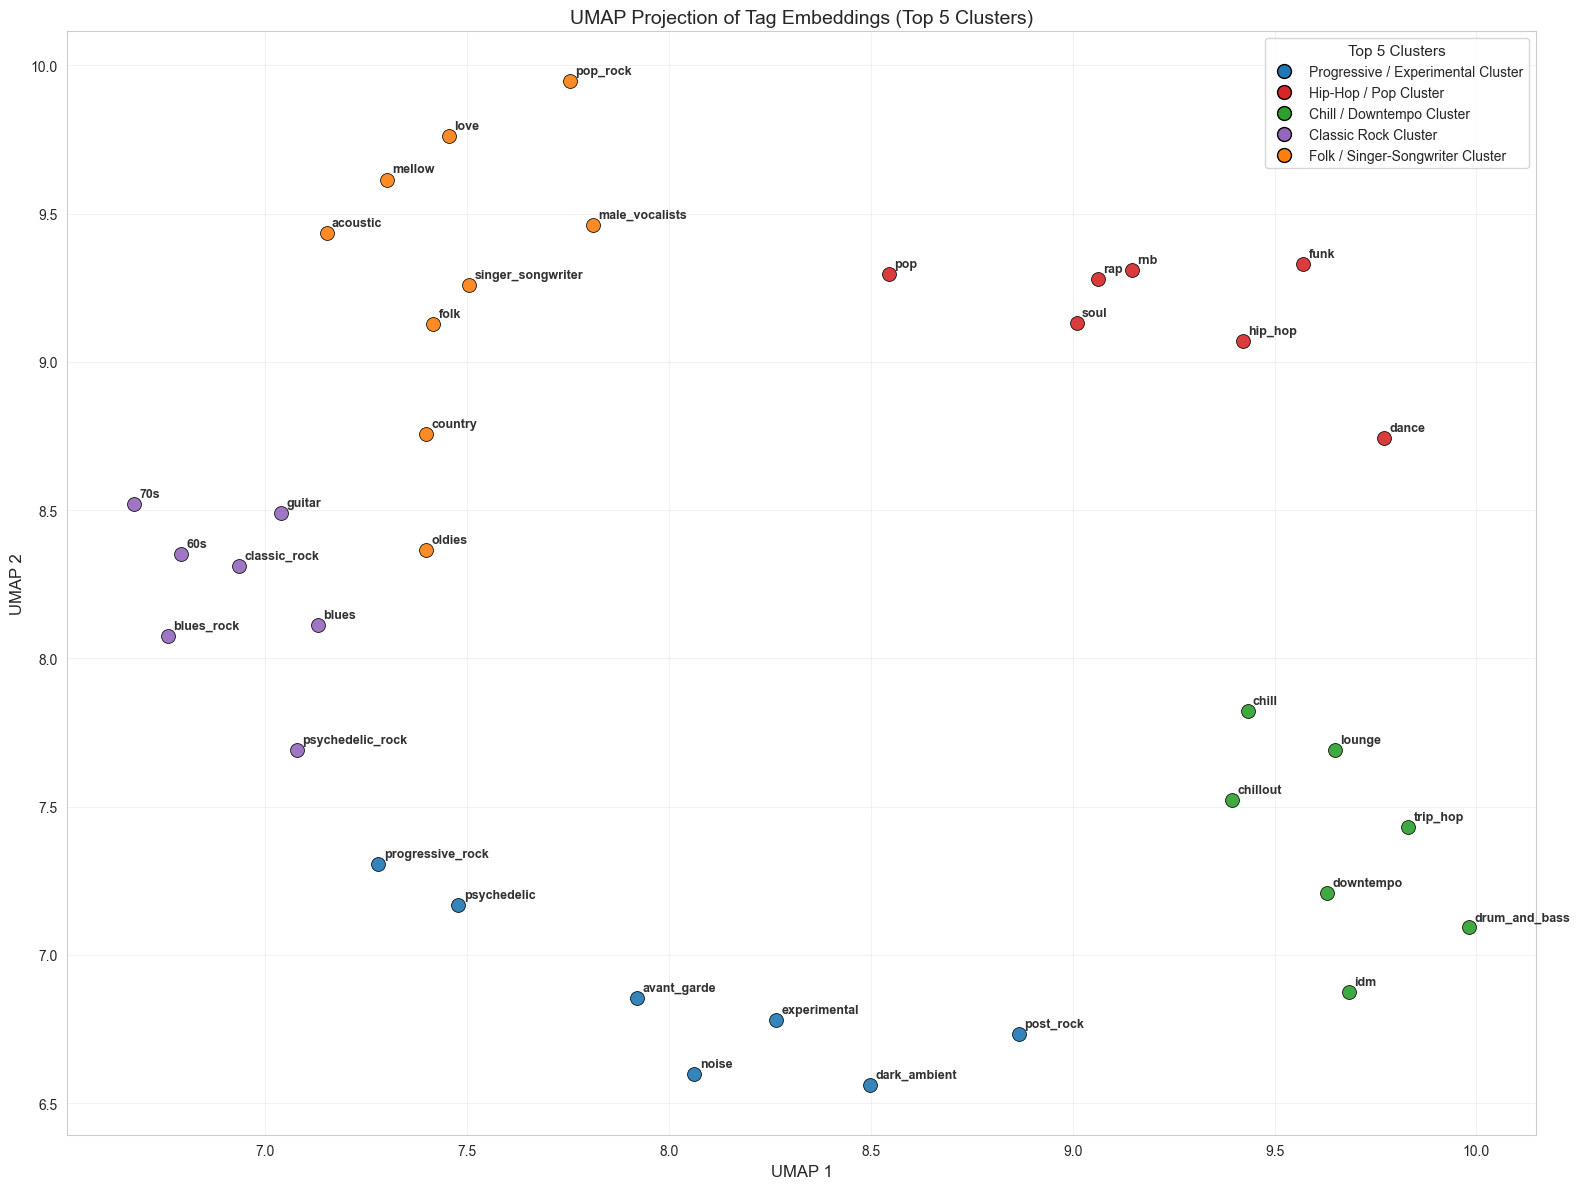

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.lines import Line2D

# Inputs expected:
# embedding_2d : array of shape (n_tags, 2)
# tag_keys : list/array of tag strings
# tag_cluster_map : dict mapping tag -> cluster id

# Optional: clean human-readable names for clusters
cluster_display_names = {
    18: "Indie Rock Cluster",
    10: "Hip-Hop / Pop Cluster",
    16: "Classic Rock Cluster",
    17: "Folk / Singer-Songwriter Cluster",
    5: "Progressive / Experimental Cluster",
    11: "Electronic / Dance Cluster",
    3: "Death Metal Cluster",
    1: "Black Metal Cluster",
    15: "Punk Cluster",
    7: "Ambient / Instrumental Cluster",
    12: "Chill / Downtempo Cluster"
}

# --- Step 1: Map tags to clusters ---
tag_keys_arr = np.array(tag_keys)
clusters = np.array([tag_cluster_map[tag] for tag in tag_keys_arr])

# --- Step 2: Keep top 5 largest clusters ---
cluster_counts = Counter(clusters)
top_clusters = [c for c, _ in cluster_counts.most_common(5)]

mask = np.isin(clusters, top_clusters)
X = embedding_2d[mask]
y = clusters[mask]
tags = tag_keys_arr[mask]

# --- Step 3: Create readable cluster names for legend ---
cluster_names = {}
for cluster in top_clusters:
    if cluster in cluster_display_names:
        cluster_names[cluster] = cluster_display_names[cluster]
    else:
        cluster_tags = [tag for tag, c in tag_cluster_map.items() if c == cluster]
        cluster_names[cluster] = ", ".join(cluster_tags[:3])

# --- Step 4: Custom clean color palette (no brown) ---
color_list = [
    "#1f77b4",  # blue
    "#d62728",  # red
    "#2ca02c",  # green
    "#9467bd",  # purple
    "#ff7f0e",  # orange
    "#ffff0e",  # yellow
]

unique_clusters = np.array(sorted(np.unique(y)))
colors = {cluster: color_list[i] for i, cluster in enumerate(unique_clusters)}

# --- Step 5: Plot ---
fig, ax = plt.subplots(figsize=(16, 12))

for cluster in unique_clusters:
    idx = np.where(y == cluster)[0]
    cluster_points = X[idx]

    ax.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=100,
        alpha=0.9,
        color=colors[cluster],
        edgecolor="black",
        linewidth=0.6,
        label=cluster_names[cluster]
    )

# --- Step 6: Label most central tags in each cluster (offset to upper-right) ---

# compute dynamic offset based on plot scale
x_range = X[:, 0].max() - X[:, 0].min()
y_range = X[:, 1].max() - X[:, 1].min()

dx = 0.004 * x_range
dy = 0.004 * y_range

for cluster in unique_clusters:
    idx = np.where(y == cluster)[0]
    cluster_points = X[idx]
    cluster_tags = tags[idx]

    centroid = cluster_points.mean(axis=0)
    distances = np.linalg.norm(cluster_points - centroid, axis=1)

    n_labels = min(10, len(idx))
    central_idx = np.argsort(distances)[:n_labels]

    for j in central_idx:
        x, y_ = cluster_points[j]

        ax.text(
            x + dx,
            y_ + dy,
            cluster_tags[j],
            fontsize=9,
            weight="bold",
            alpha=0.95,
            ha="left",   # align text to the right of the point
            va="bottom"  # align text above the point
        )

# --- Step 7: Legend ---
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[cluster],
        markeredgecolor='black',
        markersize=10,
        label=cluster_names[cluster]
    )
    for cluster in unique_clusters
]

ax.legend(
    handles=legend_handles,
    title="Top 5 Clusters",
    loc="best",
    fontsize=10,
    title_fontsize=11
)

ax.set_title("UMAP Projection of Tag Embeddings (Top 5 Clusters)", fontsize=14)
ax.set_xlabel("UMAP 1", fontsize=12)
ax.set_ylabel("UMAP 2", fontsize=12)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# Optional save:
# plt.savefig("tag_clusters_top5.png", dpi=300, bbox_inches="tight")

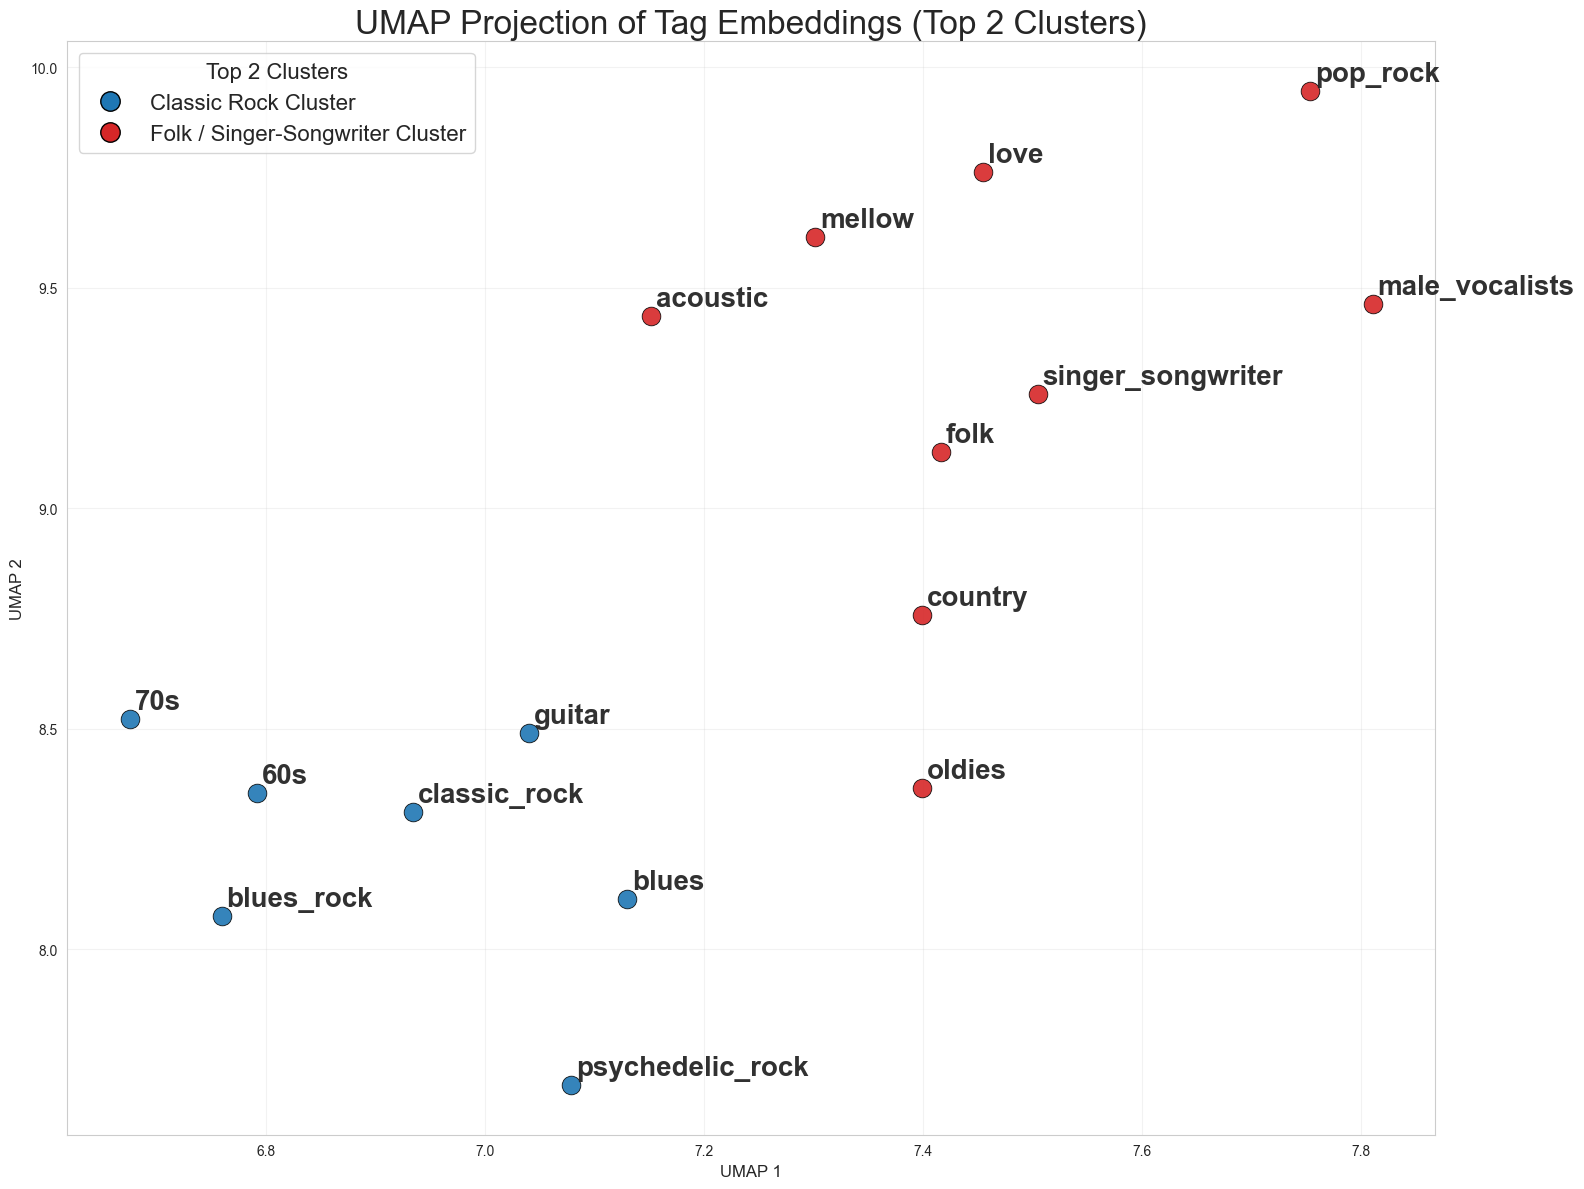

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.lines import Line2D

# Inputs expected:
# embedding_2d : array of shape (n_tags, 2)
# tag_keys : list/array of tag strings
# tag_cluster_map : dict mapping tag -> cluster id

# Optional: clean human-readable names for clusters
cluster_display_names = {
    18: "Indie Rock Cluster",
    10: "Hip-Hop / Pop Cluster",
    16: "Classic Rock Cluster",
    17: "Folk / Singer-Songwriter Cluster",
    5: "Progressive / Experimental Cluster",
    11: "Electronic / Dance Cluster",
    3: "Death Metal Cluster",
    1: "Black Metal Cluster",
    15: "Punk Cluster",
    7: "Ambient / Instrumental Cluster",
    12: "Chill / Downtempo Cluster"
}

# --- Step 1: Map tags to clusters ---
tag_keys_arr = np.array(tag_keys)
clusters = np.array([tag_cluster_map[tag] for tag in tag_keys_arr])

# --- Step 2: Keep top 5 largest clusters ---
cluster_counts = Counter(clusters)
top_clusters = [c for c, _ in cluster_counts.most_common(2)]

mask = np.isin(clusters, top_clusters)
X = embedding_2d[mask]
y = clusters[mask]
tags = tag_keys_arr[mask]

# --- Step 3: Create readable cluster names for legend ---
cluster_names = {}
for cluster in top_clusters:
    if cluster in cluster_display_names:
        cluster_names[cluster] = cluster_display_names[cluster]
    else:
        cluster_tags = [tag for tag, c in tag_cluster_map.items() if c == cluster]
        cluster_names[cluster] = ", ".join(cluster_tags[:3])

# --- Step 4: Custom clean color palette (no brown) ---
color_list = [
    "#1f77b4",  # blue
    "#d62728",  # red
    "#2ca02c",  # green
    "#9467bd",  # purple
    "#ff7f0e",  # orange
    "#ffff0e",  # yellow
]

unique_clusters = np.array(sorted(np.unique(y)))
colors = {cluster: color_list[i] for i, cluster in enumerate(unique_clusters)}

# --- Step 5: Plot ---
fig, ax = plt.subplots(figsize=(16, 12))

for cluster in unique_clusters:
    idx = np.where(y == cluster)[0]
    cluster_points = X[idx]

    ax.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=180,
        alpha=0.9,
        color=colors[cluster],
        edgecolor="black",
        linewidth=0.6,
        label=cluster_names[cluster]
    )

# --- Step 6: Label most central tags in each cluster (offset to upper-right) ---

# compute dynamic offset based on plot scale
x_range = X[:, 0].max() - X[:, 0].min()
y_range = X[:, 1].max() - X[:, 1].min()

dx = 0.004 * x_range
dy = 0.004 * y_range

for cluster in unique_clusters:
    idx = np.where(y == cluster)[0]
    cluster_points = X[idx]
    cluster_tags = tags[idx]

    centroid = cluster_points.mean(axis=0)
    distances = np.linalg.norm(cluster_points - centroid, axis=1)

    n_labels = min(10, len(idx))
    central_idx = np.argsort(distances)[:n_labels]

    for j in central_idx:
        x, y_ = cluster_points[j]

        ax.text(
            x + dx,
            y_ + dy,
            cluster_tags[j],
            fontsize=20,
            weight="bold",
            alpha=0.95,
            ha="left",   # align text to the right of the point
            va="bottom"  # align text above the point
        )

# --- Step 7: Legend ---
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=colors[cluster],
        markeredgecolor='black',
        markersize=14,
        label=cluster_names[cluster]
    )
    for cluster in unique_clusters
]

ax.legend(
    handles=legend_handles,
    title="Top 2 Clusters",
    loc="best",
    fontsize=16,
    title_fontsize=16
)

ax.set_title("UMAP Projection of Tag Embeddings (Top 2 Clusters)", fontsize=24)
ax.set_xlabel("UMAP 1", fontsize=12)
ax.set_ylabel("UMAP 2", fontsize=12)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# Optional save:
# plt.savefig("tag_clusters_top5.png", dpi=300, bbox_inches="tight")